In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from random import sample

# Исходный текст
text = """
мой дядя самых честных правил,
когда не в шутку занемог,
он уважать себя заставил
и лучше выдумать не мог.
его пример другим наука;
но, боже мой, какая скука
с больным сидеть и день и ночь,
не отходя ни шагу прочь!
какое низкое коварство
полуживого забавлять,
ему подушки поправлять,
печально подносить лекарство,
вздыхать и думать про себя:
когда же черт возьмет тебя!

ii

так думал молодой повеса,
летя в пыли на почтовых,
всевышней волею зевеса
наследник всех своих родных. —
друзья людмилы и руслана!
с героем моего романа
без предисловий, сей же час
позвольте познакомить вас:
онегин, добрый мой приятель,
родился на брегах невы,
где, может быть, родились вы
или блистали, мой читатель;
там некогда гулял и я:
но вреден север для меня

iii
"""

# Шаг 1: Загрузка данных
def load_data(text):
    return text.lower().split()

# Шаг 2: Создание словаря
def create_vocab(words):
    counter = Counter(words)
    vocab = {word: i + 2 for i, (word, _) in enumerate(counter.items())}
    vocab['<PAD>'] = 0
    vocab['<UNK>'] = 1
    return vocab

# Шаг 3: Предобработка данных
def preprocess_data(words, vocab):
    return [vocab.get(word, vocab['<UNK>']) for word in words]

# Шаг 4: Обучение модели
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(VanillaRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h_prev):
        x_emb = self.embedding(x)
        rnn_out, h_next = self.rnn(x_emb, h_prev)
        logits = self.fc(rnn_out)
        return logits, h_next

    def initial_state(self, batch_size):
        return torch.zeros(1, batch_size, self.rnn.hidden_size)

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h_prev):
        x_emb = self.embedding(x)
        lstm_out, (h_next, c_next) = self.lstm(x_emb, h_prev)
        logits = self.fc(lstm_out)
        return logits, (h_next, c_next)

    def initial_state(self, batch_size):
        return (torch.zeros(1, batch_size, self.lstm.hidden_size),
                torch.zeros(1, batch_size, self.lstm.hidden_size))

def train_model(model, data, vocab, epochs=1000, batch_size=32, seq_length=16):
    optimizer = optim.Adam(model.parameters())
    criterion = nn.CrossEntropyLoss(ignore_index=vocab['<PAD>'])
    history = []

    for epoch in range(epochs):
        batch_ix = torch.tensor(sample(data, batch_size), dtype=torch.int64).view(batch_size, -1)
        batch_ix = batch_ix[:, :seq_length]

        h_prev = model.initial_state(batch_size)
        logits, _ = model(batch_ix, h_prev)

        predictions_logits = logits[:, :-1]
        actual_next_tokens = batch_ix[:, 1:]

        loss = criterion(predictions_logits.reshape(-1, len(vocab)), actual_next_tokens.reshape(-1))
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        history.append(loss.item())
        if (epoch+1)%100==0:
            #clear_output(True)
            plt.plot(history,label='loss')
            plt.legend()
            plt.show()

    return history

# Шаг 5: Генерация текста
def generate_text(model, vocab, start_words, length=100):
    model.eval()
    start_idx = [vocab.get(word, vocab['<UNK>']) for word in start_words]
    input_seq = torch.tensor(start_idx, dtype=torch.int64).unsqueeze(0)
    h_prev = model.initial_state(1)

    generated_text = start_words
    for _ in range(length):
        logits, h_prev = model(input_seq, h_prev)
        next_word_idx = torch.argmax(logits[0, -1], dim=0).item()
        next_word = [word for word, idx in vocab.items() if idx == next_word_idx][0]
        generated_text.append(next_word)
        input_seq = torch.cat((input_seq, torch.tensor([[next_word_idx]], dtype=torch.int64)), dim=1)

    return generated_text

# Загрузка данных
words = load_data(text)
print(words)

['мой', 'дядя', 'самых', 'честных', 'правил,', 'когда', 'не', 'в', 'шутку', 'занемог,', 'он', 'уважать', 'себя', 'заставил', 'и', 'лучше', 'выдумать', 'не', 'мог.', 'его', 'пример', 'другим', 'наука;', 'но,', 'боже', 'мой,', 'какая', 'скука', 'с', 'больным', 'сидеть', 'и', 'день', 'и', 'ночь,', 'не', 'отходя', 'ни', 'шагу', 'прочь!', 'какое', 'низкое', 'коварство', 'полуживого', 'забавлять,', 'ему', 'подушки', 'поправлять,', 'печально', 'подносить', 'лекарство,', 'вздыхать', 'и', 'думать', 'про', 'себя:', 'когда', 'же', 'черт', 'возьмет', 'тебя!', 'ii', 'так', 'думал', 'молодой', 'повеса,', 'летя', 'в', 'пыли', 'на', 'почтовых,', 'всевышней', 'волею', 'зевеса', 'наследник', 'всех', 'своих', 'родных.', '—', 'друзья', 'людмилы', 'и', 'руслана!', 'с', 'героем', 'моего', 'романа', 'без', 'предисловий,', 'сей', 'же', 'час', 'позвольте', 'познакомить', 'вас:', 'онегин,', 'добрый', 'мой', 'приятель,', 'родился', 'на', 'брегах', 'невы,', 'где,', 'может', 'быть,', 'родились', 'вы', 'или', 'блис

In [4]:
# Создание словаря
vocab = create_vocab(words)
print(vocab)

{'мой': 2, 'дядя': 3, 'самых': 4, 'честных': 5, 'правил,': 6, 'когда': 7, 'не': 8, 'в': 9, 'шутку': 10, 'занемог,': 11, 'он': 12, 'уважать': 13, 'себя': 14, 'заставил': 15, 'и': 16, 'лучше': 17, 'выдумать': 18, 'мог.': 19, 'его': 20, 'пример': 21, 'другим': 22, 'наука;': 23, 'но,': 24, 'боже': 25, 'мой,': 26, 'какая': 27, 'скука': 28, 'с': 29, 'больным': 30, 'сидеть': 31, 'день': 32, 'ночь,': 33, 'отходя': 34, 'ни': 35, 'шагу': 36, 'прочь!': 37, 'какое': 38, 'низкое': 39, 'коварство': 40, 'полуживого': 41, 'забавлять,': 42, 'ему': 43, 'подушки': 44, 'поправлять,': 45, 'печально': 46, 'подносить': 47, 'лекарство,': 48, 'вздыхать': 49, 'думать': 50, 'про': 51, 'себя:': 52, 'же': 53, 'черт': 54, 'возьмет': 55, 'тебя!': 56, 'ii': 57, 'так': 58, 'думал': 59, 'молодой': 60, 'повеса,': 61, 'летя': 62, 'пыли': 63, 'на': 64, 'почтовых,': 65, 'всевышней': 66, 'волею': 67, 'зевеса': 68, 'наследник': 69, 'всех': 70, 'своих': 71, 'родных.': 72, '—': 73, 'друзья': 74, 'людмилы': 75, 'руслана!': 76, 

In [ ]:
# Предобработка данных
data = preprocess_data(words, vocab)
print(data)

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 8, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 16, 32, 16, 33, 8, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 16, 50, 51, 52, 7, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 9, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 16, 76, 29, 77, 78, 79, 80, 81, 82, 53, 83, 84, 85, 86, 87, 88, 2, 89, 90, 64, 91, 92, 93, 94, 95, 96, 97, 98, 99, 2, 100, 101, 102, 103, 16, 104, 105, 106, 107, 108, 109, 110]


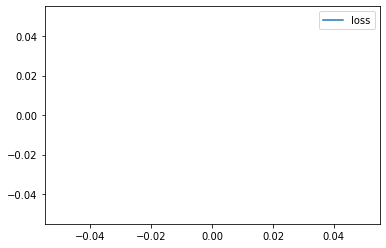

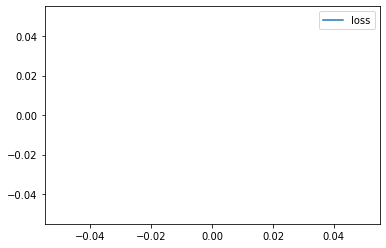

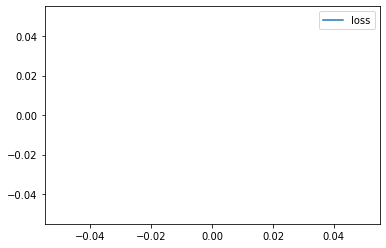

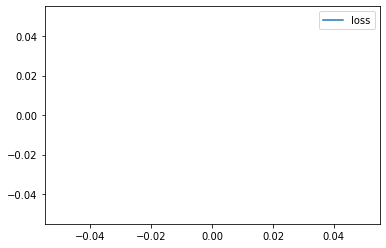

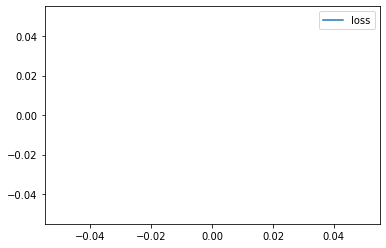

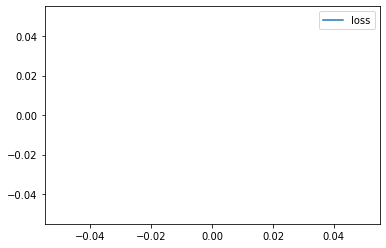

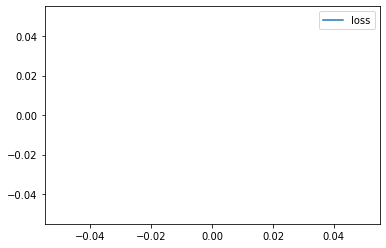

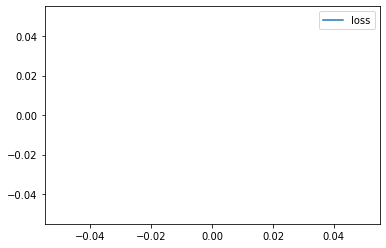

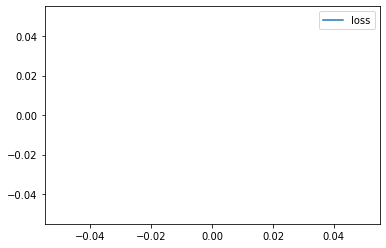

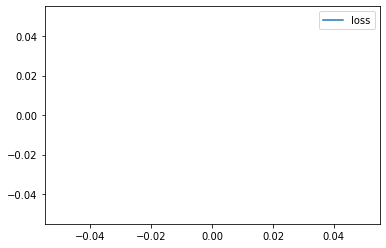

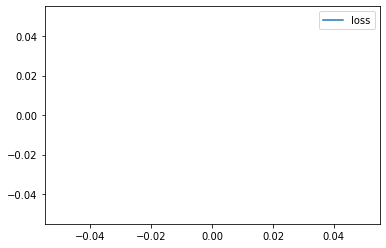

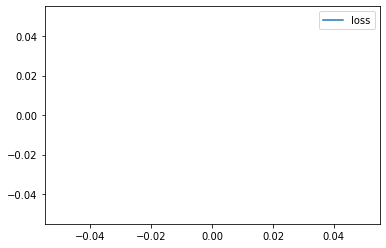

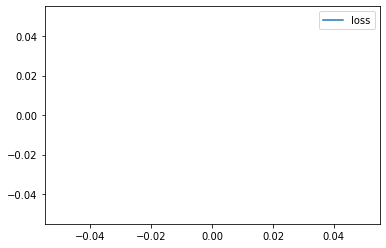

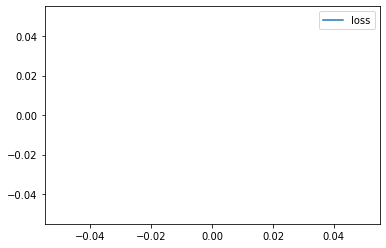

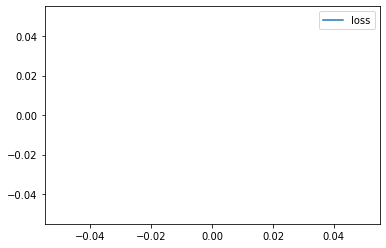

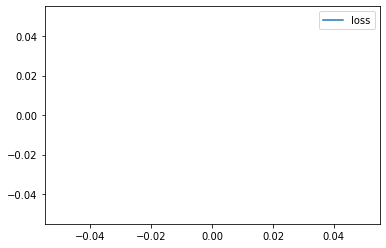

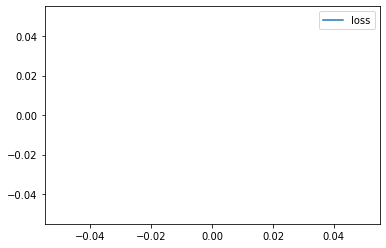

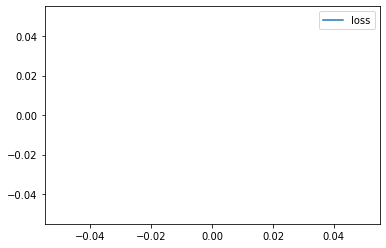

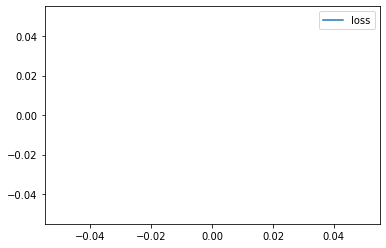

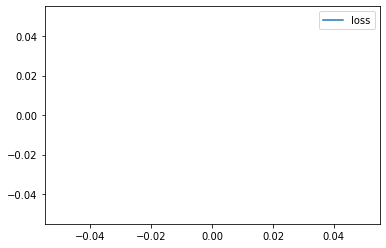

Generated text with Vanilla RNN:
мой дядя быть, себя: его быть, правил, час день и думать вреден сидеть его всех себя: <PAD> честных не правил, для себя: честных приятель, некогда час день и думать вреден сидеть его всех себя: <PAD> честных не правил, для себя: честных приятель, некогда час день и думать вреден сидеть его всех себя: <PAD> честных не правил, для себя: честных приятель, некогда час день и думать вреден сидеть его всех себя: <PAD> честных не правил, для себя: честных приятель, некогда час день и думать вреден сидеть его всех себя: <PAD> честных не правил, для себя: честных приятель, некогда час день и думать вреден полуживого читатель; он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он он

Generated text with LSTM:
мой дядя быть, себя: 

In [ ]:
# Обучение модели Vanilla RNN
vanilla_rnn = VanillaRNN(len(vocab), embedding_dim=18, hidden_dim=64)
train_model(vanilla_rnn, data, vocab)

# Обучение модели LSTM
lstm_model = LSTMModel(len(vocab), embedding_dim=18, hidden_dim=64)
train_model(lstm_model, data, vocab)

# Генерация текста
start_words = ["мой", "дядя"]
generated_text_rnn = generate_text(vanilla_rnn, vocab, start_words)
generated_text_lstm = generate_text(lstm_model, vocab, start_words)

print("Generated text with Vanilla RNN:")
print(" ".join(generated_text_rnn))

print("\nGenerated text with LSTM:")
print(" ".join(generated_text_lstm))